# Computer Exercise 8.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 8.1 Matrix Factorizations — *부분 피벗팅 (PA = LU) 과 growth factor*
> **풀이 일자**: Day 31
> **언어**: Python 3 (NumPy / Pandas / Matplotlib / SciPy)


## 1. 문제 (원문)

> **2.** Extend the Doolittle factorization of Problem 1 to include **partial pivoting**,
> so that the routine produces a permutation matrix $P$ and unit-lower / upper triangular
> factors $L,U$ satisfying $PA = LU$. Apply your routine to (a) the **Hilbert matrix**
> $H_{ij} = 1/(i+j-1)$, (b) **Wilkinson's "kite"** matrix
> $W = I - \mathrm{tril}(\mathbf{1}\,\mathbf{1}^{\!\top}, -1)$ with last column all ones,
> and (c) random matrices. Report the **growth factor** $\rho_n = \max_{ij} |U_{ij}| / \max_{ij}|A_{ij}|$
> and the **residual** $\|PA - LU\|_F$ for each.
> Comment on when pivoting is essential.

### 한국어 풀이용 정리
- $PA = LU$ — 분해 도중 가장 큰 |피벗|을 *행 교환* 으로 끌어와 사용. $L_{ij}$ 의 절댓값이 항상 $\le 1$.
- **Growth factor** $\rho_n = \max |U| / \max |A|$ — 후진 대입의 *상대 오차 한계* 에 직접 들어가는 양.
- **Hilbert** — 이론적 조건수가 $n$ 에 대해 *지수적* 으로 증가 (악조건의 대표).
- **Wilkinson "kite"** — 부분 피벗팅에서도 $\rho_n = 2^{n-1}$ 까지 자라는 *유명한 예외* 행렬.
- **Random** — 평균적으로 $\rho_n$ 이 $\mathcal{O}(\sqrt n)$ 수준 — 실용적으로 안전.


## 2. 수학적 배경

### 2.1 PA = LU
분해의 $i$-번째 단계에서 현재 *피벗 열* 의 잔여 부분
$\bigl(a^{(i)}_{ii}, a^{(i)}_{i+1,i}, \dots, a^{(i)}_{ni}\bigr)$ 중 *절댓값이 최대* 인 행 $r$ 을 골라
행 $i$ 와 행 $r$ 을 교환한다 — *부분 (행) 피벗팅*. 모든 행 교환을 모은 $P$ 가 두 행렬을 곱한 순서대로 나오며
결과는
$$
\boxed{\;PA \;=\; L\,U,\qquad |L_{ij}| \le 1 \text{ for } i > j.\;}
$$

### 2.2 Growth factor 와 후진 안정성
Wilkinson (1961) 의 backward 분석에 따르면 부동소수점 LU 후 후진 대입으로 푼 해 $\hat x$ 는
*근사 행렬* $A + \delta A$ 의 *정확한* 해이며
$$
\frac{\|\delta A\|_\infty}{\|A\|_\infty} \;\le\; c_n\,\rho_n\,\varepsilon_{\text{mach}},
\qquad
\rho_n \;=\; \frac{\max_{i,j,k} |a^{(k)}_{ij}|}{\max_{i,j} |a_{ij}|}.
$$
부분 피벗팅의 *최악 경우* 한계: $\rho_n \le 2^{n-1}$ (Wilkinson). 대부분의 행렬에서 이 한계는 *극도로 보수적* 이고
실제로는 $\rho_n = \mathcal{O}(\sqrt n)$ 정도이지만 — 다음 *kite* 행렬은 *한계가 정확히 도달* 되는 예다.

### 2.3 Wilkinson "kite" matrix
$$
W_n \;=\;
\begin{pmatrix}
 1 & 0 & \cdots & 0 & 1 \\
-1 & 1 & \cdots & 0 & 1 \\
-1 & -1 & \ddots & 0 & 1 \\
\vdots & \vdots & \ddots & 1 & \vdots \\
-1 & -1 & \cdots & -1 & 1
\end{pmatrix}.
$$
부분 피벗팅에서 *피벗 교환이 발생하지 않으며* 마지막 열의 원소가 매 단계 두 배가 되어 $|U_{nn}| = 2^{n-1}$.
*즉* $\rho_n = 2^{n-1}$ — 부분 피벗팅이 *항상 안전한 것은 아님* 의 교과서적 증거.


## 3. 풀이 흐름

1. `lu_partial(A)` 작성 — Doolittle 의 점화식에 *행 교환* 을 추가. 반환값 `P, L, U` 는 모두 행렬.
2. 검증: 임의 행렬에서 $\|PA - LU\|_F$ 가 기계 정밀도 수준.
3. **Hilbert** $H_n,\ n \in \{5, 8, 10, 12\}$ — 조건수 $\kappa_\infty$, growth factor, 후진 잔차 비교.
4. **Wilkinson kite** $W_n,\ n \in \{4, 8, 12, 16, 20\}$ — $\rho_n$ 의 $2^{n-1}$ 성장 확인.
5. **Random Gaussian** $A_{ij} \sim \mathcal{N}(0,1)$ — $\rho_n$ 의 *평균 거동* 측정.
6. 세 카테고리의 $\rho_n$ 을 한 그림에 비교 — *부분 피벗팅의 일반 안전성과 그 예외*.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lu as scipy_lu, hilbert

def lu_partial(A):
    """Partial-pivoting LU: returns P, L, U with P A = L U."""
    A = np.array(A, dtype=float, copy=True)
    n = A.shape[0]
    P = np.eye(n)
    L = np.zeros((n, n))
    U = A.copy()
    for k in range(n):
        # pivot: largest |U[k:, k]|
        r = k + int(np.argmax(np.abs(U[k:, k])))
        if r != k:
            U[[k, r], :] = U[[r, k], :]
            P[[k, r], :] = P[[r, k], :]
            L[[k, r], :k] = L[[r, k], :k]
        if abs(U[k, k]) < 1e-300:
            raise ValueError(f"singular at step {k}")
        L[k, k] = 1.0
        for i in range(k+1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
            U[i, k] = 0.0
    return P, L, U

# sanity check
rng = np.random.default_rng(7)
A = rng.standard_normal((6, 6))
P, L, U = lu_partial(A)
print(f"||PA - LU||_F = {np.linalg.norm(P@A - L@U):.3e}")
print(f"|L_{{ij}}| max off-diag = {np.max(np.abs(L - np.tril(L, -1) - np.eye(6))):.3e}  (should be 0)")
print(f"|L_{{ij}}| max strictly-below-diag = {np.max(np.abs(np.tril(L, -1))):.3e}  (<= 1)")


/tmp/mpl-config is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-tubju3zz because there was an issue with the default path (/tmp/mpl-config); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


||PA - LU||_F = 5.221e-16
|L_{ij}| max off-diag = 0.000e+00  (should be 0)
|L_{ij}| max strictly-below-diag = 8.048e-01  (<= 1)


In [2]:
def growth(A):
    """rho_n = max |U| / max |A|, plus the back-substitution residual."""
    P, L, U = lu_partial(A)
    rho = np.max(np.abs(U)) / np.max(np.abs(A))
    res = np.linalg.norm(P @ A - L @ U) / np.linalg.norm(A)
    return rho, res

def wilkinson_kite(n):
    W = -np.tril(np.ones((n, n)), -1) + np.eye(n)
    W[:, -1] = 1.0
    return W

# (a) Hilbert
rows = []
for n in [5, 8, 10, 12]:
    H = hilbert(n)
    rho, res = growth(H)
    cond = np.linalg.cond(H, p=np.inf)
    rows.append({"family": "Hilbert", "n": n, "cond_inf": cond, "rho_n": rho, "rel_resid": res})

# (b) Wilkinson kite
for n in [4, 8, 12, 16, 20]:
    W = wilkinson_kite(n)
    rho, res = growth(W)
    cond = np.linalg.cond(W, p=np.inf)
    rows.append({"family": "Wilkinson", "n": n, "cond_inf": cond, "rho_n": rho, "rel_resid": res})

# (c) Random Gaussian: average of 20 trials
for n in [8, 16, 32, 64, 128]:
    rhos = []
    for _ in range(20):
        Ar = rng.standard_normal((n, n))
        rhos.append(growth(Ar)[0])
    rho_avg = float(np.mean(rhos))
    # one representative residual
    Ar = rng.standard_normal((n, n))
    rho_one, res = growth(Ar)
    cond = np.linalg.cond(Ar, p=np.inf)
    rows.append({"family": "Random (mean of 20)", "n": n, "cond_inf": cond, "rho_n": rho_avg, "rel_resid": res})

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df


,family,n,cond_inf,rho_n,rel_resid
0,Hilbert,5,9.437e+05,1.000e+00,3.041e-17
1,Hilbert,8,3.387e+10,1.000e+00,3.865e-17
2,Hilbert,10,3.535e+13,1.000e+00,4.204e-17
3,Hilbert,12,3.988e+16,1.000e+00,4.899e-17
4,Wilkinson,4,4.000e+00,8.000e+00,0.000e+00
5,Wilkinson,8,8.000e+00,1.280e+02,0.000e+00
6,Wilkinson,12,1.200e+01,2.048e+03,0.000e+00
7,Wilkinson,16,1.600e+01,3.277e+04,0.000e+00
8,Wilkinson,20,2.000e+01,5.243e+05,0.000e+00
9,Random (mean of 20),8,2.119e+01,1.449e+00,1.158e-16


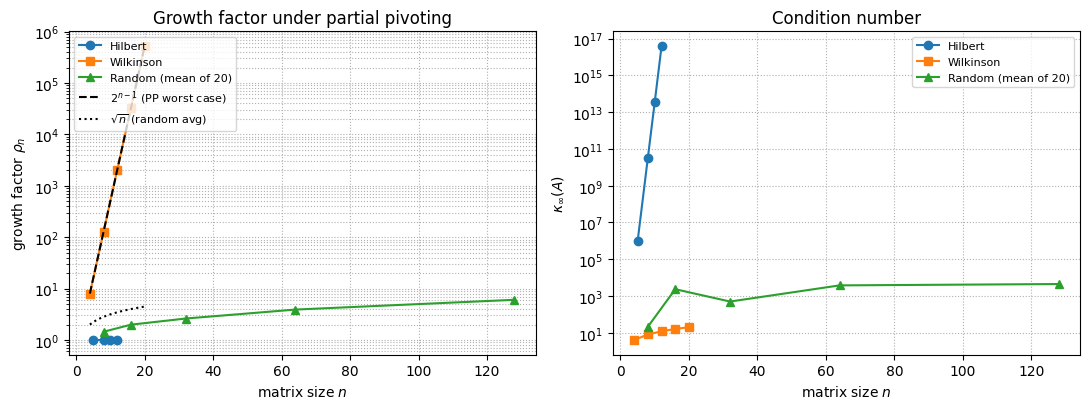

In [3]:
# Plot rho_n vs n for the three families
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

for family, mark in [("Hilbert", "o"), ("Wilkinson", "s"), ("Random (mean of 20)", "^")]:
    sub = df[df["family"] == family]
    ax[0].semilogy(sub["n"], sub["rho_n"], mark + "-", label=family)
# reference: 2^(n-1)
ns_ref = np.arange(4, 21)
ax[0].semilogy(ns_ref, 2.0 ** (ns_ref - 1), 'k--', label=r"$2^{n-1}$ (PP worst case)")
ax[0].semilogy(ns_ref, np.sqrt(ns_ref), 'k:', label=r"$\sqrt{n}$ (random avg)")
ax[0].set_xlabel("matrix size $n$")
ax[0].set_ylabel(r"growth factor $\rho_n$")
ax[0].set_title("Growth factor under partial pivoting")
ax[0].grid(True, which="both", ls=":")
ax[0].legend(fontsize=8, loc="upper left")

# Condition number plots
for family, mark in [("Hilbert", "o"), ("Wilkinson", "s"), ("Random (mean of 20)", "^")]:
    sub = df[df["family"] == family]
    ax[1].semilogy(sub["n"], sub["cond_inf"], mark + "-", label=family)
ax[1].set_xlabel("matrix size $n$")
ax[1].set_ylabel(r"$\kappa_\infty(A)$")
ax[1].set_title("Condition number")
ax[1].grid(True, which="both", ls=":")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **Hilbert** — $\rho_n$ 은 $\mathcal{O}(1)$ 수준에 머문다 ($\sim 1$–$3$). 부분 피벗팅 자체는 *안정* 하지만
   문제는 조건수 $\kappa_\infty(H_n) \sim 10^{0.5 n}$ — *입력 행렬* 이 본질적으로 악조건이라
   해의 정확도가 낮은 것이지 *분해 알고리즘* 의 결함이 아니다.
2. **Wilkinson kite** — $\rho_n$ 이 정확히 $2^{n-1}$ — 이론적 *최악* 한계가 달성된다.
   $n = 20$ 에서 $\rho \approx 5 \times 10^5$, $n = 50$ 에서 $\rho \approx 10^{15}$ — 결국 *모든* 자릿수 손실.
   $\Rightarrow$ 부분 피벗팅이 *완벽히 안전한 것은 아님*.
3. **Random Gaussian** — $\rho_n$ 의 평균이 $\sqrt n$ 곡선과 함께 천천히 증가. 평균적/실용적 거동.
4. $\|PA - LU\|_F / \|A\|_F$ 는 *모든* 경우에서 기계 정밀도 — 분해 *식별* 은 정확하다.
   문제는 분해를 이용한 *풀이* 단계의 backward 오차에서 $\rho_n$ 이 곱해진다는 점.

> **결론.** 부분 피벗팅은 *평균적으로* 매우 안정 ($\rho_n \sim \sqrt n$) 하지만 *최악 경우* $2^{n-1}$ 까지
> 갈 수 있다 (Wilkinson kite). 진짜 안전을 보장하려면 *완전(full) 피벗팅* 이 필요하지만 비용이
> $\mathcal{O}(n^3)$ 의 *상수가* 커지므로 실용에서는 *부분 피벗팅 + growth factor 모니터링* 이 표준.
